## පරීක්ෂණය: "Credit Risk Classification"
බැංකුවකින් ණය (Loan) ලබා දිය යුතුද නැද්ද යන්න තීරණය කරන මොඩල් එකක් හදන්න.

- Dataset: Credit Risk Dataset (Kaggle) - මේකේ missing values සහ categorical data ඕනෑතරම් තියෙනවා.

#### අවශ්‍යතාවයන්:

- Pipeline එකක් අනිවාර්යයෙන්ම තිබිය යුතුයි.

- Missing values සඳහා SimpleImputer පාවිච්චි කරන්න.

- දත්ත Scale කරන්න.

- K-Nearest Neighbors (KNN) හෝ Random Forest මොඩල් එකක් පාවිච්චි කරන්න (Logistic Regression නෙවෙයි).

- Hyperparameter tuning හරහා හොඳම මොඩල් එක හොයන්න.

- අවසානයේ Confusion Matrix එකක් සහ Classification Report එකක් GitHub Repo එකේ README එකේ දාන්න.

In [1]:
# Load data
import pandas as pd
data = pd.read_csv("../Data/credit_risk_dataset.csv")

# check data set first 5 rows

print(data.columns)
data.head()

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
# check null values
data.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [3]:
# check data types and null values

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

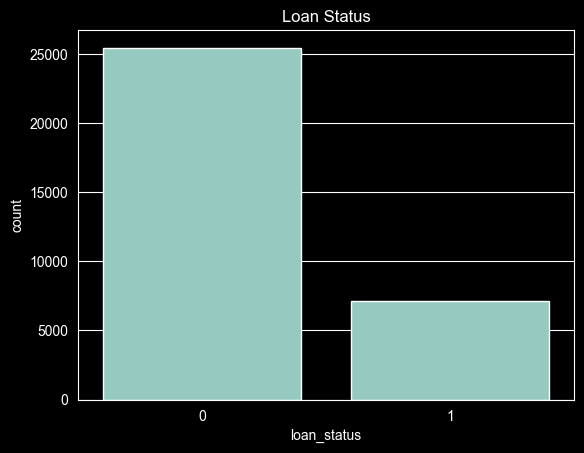

In [5]:
# target Distribution
sns.countplot(x='loan_status', data=data)
plt.title('Loan Status')
plt.show()

In [6]:
# Feature Matrix (X) and Target Vector (y)

X = data.drop('loan_status', axis=1)
y = data['loan_status']

In [7]:
# categorical features to dummy variables
X_encoded =pd.get_dummies(X, drop_first=True)

# check new shapes columns
# check new shape columns
print("Original shape of X:", X.shape)
print("Encoded shape of X:", X_encoded.shape)
print("\nNew Columns in X_encoded:\n", X_encoded.columns)

X_encoded.head()

Original shape of X: (32581, 11)
Encoded shape of X: (32581, 22)

New Columns in X_encoded:
 Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B',
       'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'loan_grade_G', 'cb_person_default_on_file_Y'],
      dtype='str')


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression


steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('RandomForest', RandomForestClassifier(n_estimators=100,class_weight='balanced', random_state=42)),
    # ('logreg', LogisticRegression())  # Logistic Regression model
]

# create pipeLine
pipeline = Pipeline(steps)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [9]:
# Train/Test Split and Pipeline Fit
from sklearn.model_selection import train_test_split

# train 80%
# test 20%

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (26064, 22)
Testing data shape: (6517, 22)


In [10]:
# train the pipeline
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [11]:
# check accuracy on the test set
accuracy = pipeline.score(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%" )


Accuracy: 93.22%


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = pipeline.predict(X_test)
print(accuracy_score(y_test, y_pred))


0.9321773822310879


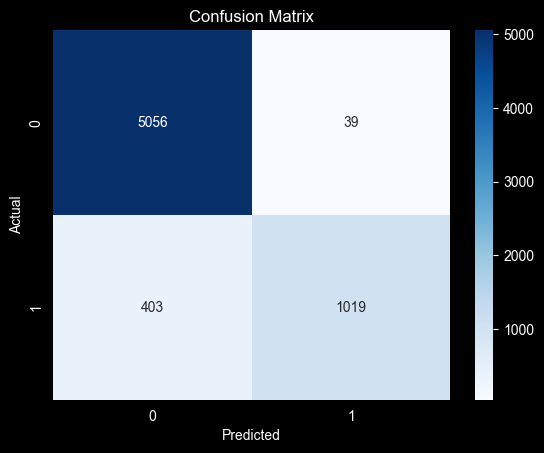


Classification Report: 
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.96      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517



In [13]:
cm = confusion_matrix(y_test, y_pred)

# heatmap
sns.heatmap(data=cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# classification_report
report = classification_report(y_test, y_pred)
print(f"\nClassification Report: \n{report}")


In [14]:
# Hyperparameter Tuning (The Final Polish)
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = {
    'RandomForest__n_estimators': [100, 200],
    'RandomForest__max_depth': [None, 10, 20],
    'RandomForest__min_samples_split': [2, 5, 10],
    'RandomForest__bootstrap': [True, False],
    'RandomForest__max_features': ['sqrt', 'log2']
}


grid_search =GridSearchCV(pipeline, param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f"Best parameters:\n {grid_search.best_params_}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters:
 {'RandomForest__bootstrap': False, 'RandomForest__max_depth': 20, 'RandomForest__max_features': 'sqrt', 'RandomForest__min_samples_split': 2, 'RandomForest__n_estimators': 200}


In [15]:
# 1. Best model එකෙන් test දත්ත සඳහා predictions ලබා ගැනීම
# මෙහිදී grid_search විසින් ඉබේම අර best parameters ටික පාවිච්චි කරනවා
y_pred_best = grid_search.predict(X_test)

# 2. අලුත් Accuracy සහ Classification Report එක බැලීම
print("--- Best Model Performance ---")

# Accuracy ගණනය කිරීම
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {best_accuracy * 100:.2f}%\n")

# සම්පූර්ණ Report එක (Recall, Precision, F1)
print("Classification Report:")
print(classification_report(y_test, y_pred_best))

--- Best Model Performance ---
Accuracy: 93.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.96      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517



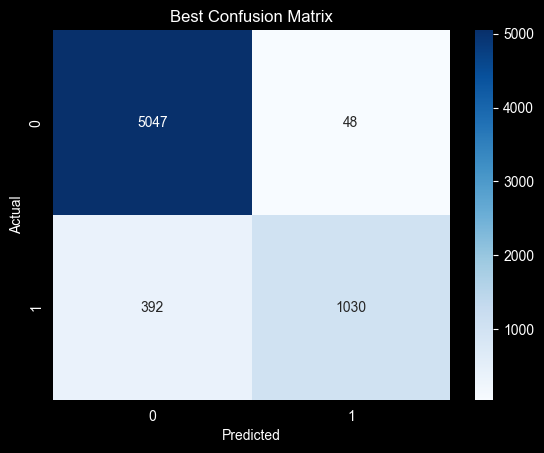

In [16]:
new_cm = confusion_matrix(y_test, y_pred_best)
# heatmap
sns.heatmap(data=new_cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Best Confusion Matrix")
plt.show()


In [17]:
import pickle

# අපේ Pipeline එක 'model.pkl' නමින් save කරමු
with open('model.pkl', 'wb') as f:
    pickle.dump(grid_search.best_estimator_, f)

print("Model saved successfully! 🚀")

Model saved successfully! 🚀
